# Essai de coder un algorithme de Grover avec une augmentation d'amplitude

D'après l'article, il faudrait coder dans cet ordre : 

* Step 1: Determine the number of iterations (k) using the given initial success probability (p), as per Eqn. 4.
* Step 2: If k is a natural number, set k′ = k and proceed directly to Step 8.
* Step 3: (If k is not a natural number) : Calculate the number of iterations, k′, based on the value of k,using Eqn. 9.
* Step 4: Compute the new required initial success probability (p′) using Eqn. 11.
* Step 5: Find the angle of rotation (ϕ) for the Ry operator from Eqn. 12.
* Step 6: Introduce an auxiliary qubit into the existing Grover’s or amplitude amplification algorithm and initialize it with Ry(ϕ) gate using the angle ϕ.
* Step 7: Modify the existing oracle by adding a control from the auxiliary qubit, ensuring that it marks target states only when the auxiliary qubit is in state |0⟩ (as per Eqn. 7).
* Step 8: Apply the oracle to mark the target states.
* Step 9: Apply the diffusion operator to increase the amplitude of the marked states.
* Step 10: Repeat Step 8 and Step 9, k′ times.
* Step 11: Measure the final state to obtain one of the target states with certainty.

**L'algorithme devrait ressembler à ça :**
![Algo sur lequel je vais me baser](img/deterministric_algorithm.png)


In [17]:
# Built-in modules
import math
import numpy as np

# Imports from Qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

### Variables du problème

In [ ]:


# --- 1. Paramètres du problème ---
n = 3               # Nombre de qubits de recherche
N = 2**n            # 8 états
M = 1               # 1 cible
p = M/N             # Probabilité initiale globale (0.125)


# k théorique
k = (np.pi / (4 * np.arcsin(np.sqrt(p)))) - 0.5

# k_prime (Nombre d'itérations réel, toujours entier supérieur)
k_prime = int(np.floor(k)) + 1 

# p_prime (La probabilité "ajustée")
p_prime = np.sin(np.pi / (4 * (k_prime + 0.5)))**2

# phi (L'angle pour le qubit auxiliaire)
phi = 2 * np.arccos(np.sqrt(p_prime / p))

print(f"Itérations : {k_prime}")
print(f"Angle phi : {phi:.4f} rad")

Itérations : 2
Angle phi : 1.0147 rad


### Création du circuit 


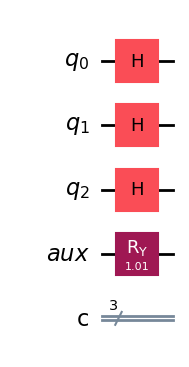

In [20]:
# On crée un registre de 3 qubits pour la recherche (nommés 'q')
q_reg = QuantumRegister(3, 'q')

# On crée un registre de 1 qubit pour l'auxiliaire (nommé 'aux')
aux_reg = QuantumRegister(1, 'aux')

# On crée un registre classique pour les résultats
c_reg = ClassicalRegister(3, 'c')

# On crée le circuit avec ces registres
circ = QuantumCircuit(q_reg, aux_reg, c_reg)

circ.h(range(3))
circ.ry(phi,aux_reg[0])
circ.draw(output="mpl", style="iqp")